# Поиск ассоциативных правил

Доработайте программу из задания Поиск частых наборов, чтобы она также выполняла поиск ассоциативных правил. Список результирующих правил должен выдаваться в удобочитаемом виде (антецедент→консеквент) с указанием поддержки и достоверности каждого правила. Дополнительные параметры программы: порог достоверности, способ упорядочивания результирующего списка наборов (по убыванию значения поддержки или лексикографическое).


Проведите эксперименты на наборах из задания 1. В экспериментах Зафиксируйте значение пороговое значение поддержки (например, 10%), варьируйте пороговое значение достоверности (например, от 70% до 95% с шагом 5%).
Выполните визуализацию полученных результатов в виде следующих диаграмм:



*   сравнение быстродействия поиска правил на фиксированном наборе данных при изменяемом пороге достоверности;
*   общее количество найденных правил на фиксированном наборе данных при изменяемом пороге достоверности.


Подготовьте список правил, в которых антецедент и консеквент суммарно включают в себя не более семи объектов (разумное количество). Проанализируйте и изложите содержательный смысл полученного результата.

# Подключение библиотек

In [4]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
import pandas as pd
import chardet
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import time
import matplotlib.pyplot as plt
import numpy as np

# Получение данных

In [6]:
df = pd.read_csv('baskets.csv', header=None, encoding='cp1251')
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,креветки,миндаль,авокадо,овощная смесь,зеленый виноград,цельнозерновая мука,батат,творог,энергетический напиток,томатный сок,низкокалорийный йогурт,зеленый чай,мед,салат,минеральная вода,лосось,ягодный сок,замороженный смузи,шпинат,оливковое масло
1,гамбургер,фрикадельки,яйца,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,чатни,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,индейка,авокадо,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,минеральная вода,молоко,энергетический батончик,рис,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,сливочное масло,низкокалорийный майонез,свежий хлеб,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,гамбургер,замороженные овощи,яйца,картофель-фри,журнал,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,курица,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,эскалоп,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим пустые строки, столбцы. Сформируем список транзакций

In [7]:
df = df.dropna(how="all", axis=0)
df = df.dropna(how="all", axis=1)

transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
print("Всего транзакций: %d" % len(transactions))
print(transactions[:5])

Всего транзакций: 7501
[['креветки', 'миндаль', 'авокадо', 'овощная смесь', 'зеленый виноград', 'цельнозерновая мука', 'батат', 'творог', 'энергетический напиток', 'томатный сок', 'низкокалорийный йогурт', 'зеленый чай', 'мед', 'салат', 'минеральная вода', 'лосось', 'ягодный сок', 'замороженный смузи', 'шпинат', 'оливковое масло'], ['гамбургер', 'фрикадельки', 'яйца'], ['чатни'], ['индейка', 'авокадо'], ['минеральная вода', 'молоко', 'энергетический батончик', 'рис', 'зеленый чай']]


Функция apriori() из mlxtend не работает с текстом. Ей нужна матрица булевых значений, чтобы мгновенно выполнятьAND при подсчете совместных покупок.

Согласно полученному результату и показателю support, наиболее популярными товарами являются "минеральная вода", "макароны" и "яйца"

In [8]:
te = TransactionEncoder()
te_transformed = te.fit(transactions).transform(transactions)
df_transformed = pd.DataFrame(te_transformed, columns=te.columns_)
df_transformed

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [10]:
def find_association_rules(df_bool, min_support=0.01, min_confidence=0.7, sort_by='support'):
    """
    Поиск частых наборов алгоритмом Apriori и генерация ассоциативных правил.
    Возвращает: (frequent_itemsets, rules_df, execution_time)
    """
    frequent_itemsets = apriori(df_bool, min_support=min_support, use_colnames=True)

    if frequent_itemsets.empty:
        return pd.DataFrame(), pd.DataFrame(), 0.0

    frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

    start_time = time.perf_counter()
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    exec_time = time.perf_counter() - start_time

    if rules.empty:
        return frequent_itemsets, pd.DataFrame(), exec_time

    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ", ".join(sorted(list(x))))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ", ".join(sorted(list(x))))
    rules['rule_str'] = rules['antecedents_str'] + " → " + rules['consequents_str']

    if sort_by == 'support':
        frequent_itemsets = frequent_itemsets.sort_values(by=["itemset_size", "support"], ascending=[True, False])
        rules = rules.sort_values(by='support', ascending=False)
    elif sort_by == 'lexical':
        frequent_itemsets = frequent_itemsets.sort_values(by='itemsets')
        rules = rules.sort_values(by='rule_str', ascending=True)

    return frequent_itemsets, rules, exec_time

In [11]:
support_threshold = 0.002
confidence_thresholds = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

support_itemsets_df = pd.DataFrame()
rules_df = pd.DataFrame()
execution_times = []
rules_count = []

for confidence_threshold in confidence_thresholds:
    print(f"\nПорог достоверности: {confidence_threshold}")

    frequent_itemsets = apriori(df_transformed, min_support=support_threshold, use_colnames=True)

    frequent_itemsets["support_threshold"] = support_threshold
    frequent_itemsets["confidence_threshold"] = confidence_threshold
    frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))

    frequent_itemsets = frequent_itemsets.sort_values(by=["itemset_size", "support"], ascending=[True, False])

    support_itemsets_df = pd.concat([support_itemsets_df, frequent_itemsets], ignore_index=True)

    start_time = time.perf_counter()
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=confidence_threshold)
    end_time = time.perf_counter()
    print(f"Время выполнения association_rules: {end_time - start_time} секунд")

    execution_times.append(end_time - start_time)
    rules_subset = rules[["antecedents", "consequents", "support", "confidence"]].copy()
    rules_subset["confidence_threshold"] = confidence_threshold

    rules_subset = rules_subset.sort_values(by=["support"], ascending=False)

    rules_df = pd.concat([rules_df, rules_subset], ignore_index=True)

    rules_count.append(len(rules_subset))

    print("\nЧастые наборы")
    display(frequent_itemsets)
    print("\nАссоциативные правила)")
    display(rules_subset)


Порог достоверности: 0.7
Время выполнения association_rules: 0.08067509599999312 секунд

Частые наборы


,support,itemsets,support_threshold,confidence_threshold,itemset_size
47,0.238368,(минеральная вода),0.002,0.7,1
42,0.187975,(макароны),0.002,0.7,1
110,0.179709,(яйца),0.002,0.7,1
28,0.170911,(картофель-фри),0.002,0.7,1
104,0.163845,(шоколад),0.002,0.7,1
...,...,...,...,...,...
2476,0.002133,"(торт, макароны, минеральная вода, яйца)",0.002,0.7,4
2480,0.002133,"(макароны, помидоры, молоко, рис)",0.002,0.7,4
2485,0.002133,"(растительное масло, минеральная вода, молоко,...",0.002,0.7,4
2487,0.002133,"(яйца, минеральная вода, молоко, торт)",0.002,0.7,4



Ассоциативные правила)


,antecedents,consequents,support,confidence,confidence_threshold
0,"(грибной соус, эскалоп)",(макароны),0.004266,0.744186,0.7
4,"(макароны, растительное масло, яйца)",(минеральная вода),0.003066,0.718750,0.7
3,"(суп, замороженные овощи, молоко)",(минеральная вода),0.003066,0.766667,0.7
5,"(оливковое масло, шоколад, замороженные овощи)",(минеральная вода),0.002800,0.700000,0.7
6,"(оливковое масло, яйца, молоко)",(минеральная вода),0.002666,0.714286,0.7
7,"(говяжий фарш, креветки, замороженные овощи)",(макароны),0.002533,0.791667,0.7
1,"(обезжиренное молоко, макароны)",(минеральная вода),0.002533,0.730769,0.7
9,"(блинчики, макароны, суп)",(минеральная вода),0.002266,0.772727,0.7
8,"(блинчики, макароны, растительное масло)",(минеральная вода),0.002266,0.739130,0.7
2,"(красное вино, индейка)",(минеральная вода),0.002133,0.727273,0.7



Порог достоверности: 0.75
Время выполнения association_rules: 0.019392324999984112 секунд

Частые наборы


...


Порог достоверности: 0.95
Время выполнения association_rules: 0.01748627500001021 секунд

Частые наборы


/tmp/ipykernel_553/4281296111.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rules_df = pd.concat([rules_df, rules_subset], ignore_index=True)


,support,itemsets,support_threshold,confidence_threshold,itemset_size
47,0.238368,(минеральная вода),0.002,0.95,1
42,0.187975,(макароны),0.002,0.95,1
110,0.179709,(яйца),0.002,0.95,1
28,0.170911,(картофель-фри),0.002,0.95,1
104,0.163845,(шоколад),0.002,0.95,1
...,...,...,...,...,...
2476,0.002133,"(торт, макароны, минеральная вода, яйца)",0.002,0.95,4
2480,0.002133,"(макароны, помидоры, молоко, рис)",0.002,0.95,4
2485,0.002133,"(растительное масло, минеральная вода, молоко,...",0.002,0.95,4
2487,0.002133,"(яйца, минеральная вода, молоко, торт)",0.002,0.95,4



Ассоциативные правила)


,antecedents,consequents,support,confidence,confidence_threshold


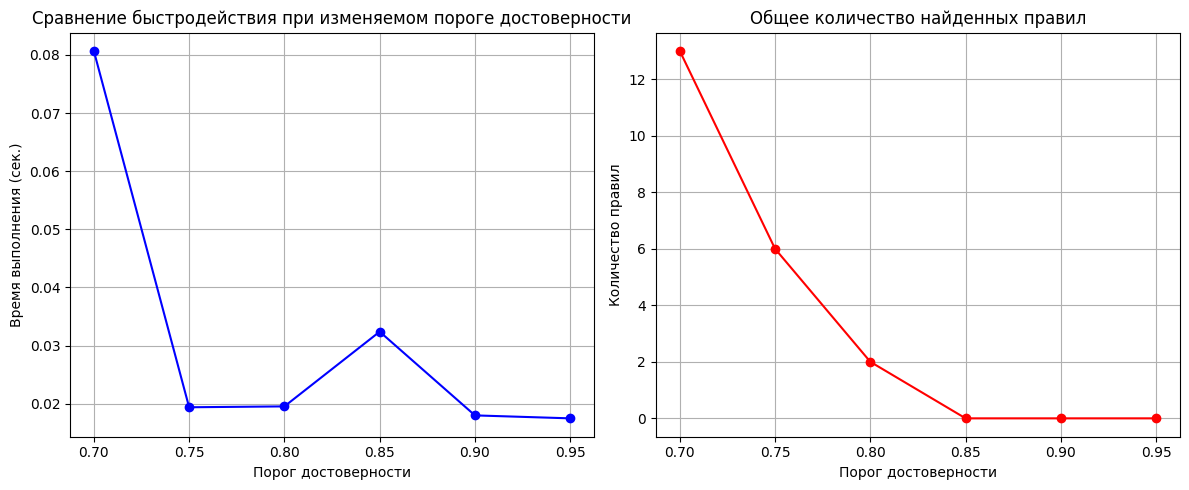

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(confidence_thresholds, execution_times, marker="o", linestyle="-", color="b")
plt.title("Сравнение быстродействия при изменяемом пороге достоверности")
plt.xlabel("Порог достоверности")
plt.ylabel("Время выполнения (сек.)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(confidence_thresholds, rules_count, marker="o", linestyle="-", color="r")
plt.title("Общее количество найденных правил")
plt.xlabel("Порог достоверности")
plt.ylabel("Количество правил")
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
filtered_rules = rules_df[rules_df.apply(lambda x: len(x["antecedents"]) + len(x["consequents"]) <= 7, axis=1)]

filtered_rules = filtered_rules[["antecedents", "consequents", "support", "confidence"]]

filtered_rules = filtered_rules.sort_values(by=["support"], ascending=False)

print("\nСписок правил с антецедентом и консеквентом <= 7 объектов:")
display(filtered_rules)


Список правил с антецедентом и консеквентом <= 7 объектов:


,antecedents,consequents,support,confidence
0,"(грибной соус, эскалоп)",(макароны),0.004266,0.744186
1,"(макароны, растительное масло, яйца)",(минеральная вода),0.003066,0.718750
2,"(суп, замороженные овощи, молоко)",(минеральная вода),0.003066,0.766667
13,"(суп, замороженные овощи, молоко)",(минеральная вода),0.003066,0.766667
3,"(оливковое масло, шоколад, замороженные овощи)",(минеральная вода),0.002800,0.700000
4,"(оливковое масло, яйца, молоко)",(минеральная вода),0.002666,0.714286
5,"(говяжий фарш, креветки, замороженные овощи)",(макароны),0.002533,0.791667
14,"(говяжий фарш, креветки, замороженные овощи)",(макароны),0.002533,0.791667
6,"(обезжиренное молоко, макароны)",(минеральная вода),0.002533,0.730769
7,"(блинчики, макароны, суп)",(минеральная вода),0.002266,0.772727
